# CNN Theory & Explanation

## 1️⃣ Why CNNs Exist
Regular Neural Networks flatten images.

Example MNIST:

> 28 × 28 image → 784 numbers

MLP treats them as:

> [0.1, 0.4, 0.9, 0.2, ...]

But this destroys spatial relationships.

Example:

> Pixel (1,1) and Pixel (1,2)

are neighbors in the image.

MLP cannot understand this.

CNN solves this.

## Real World Example

In self-driving cars:

CNN detects:

> edges → shapes → objects → pedestrians

Pipeline:


> image \
> ↓ \
> edges \
> ↓ \
> patterns \
> ↓ \
> object detection


## 2️⃣ Convolution
### What is Convolution ?
A convolution applies a small filter (kernel) over the images.
The filter slides across the image.
Each position produces a value.

### Real CNN Filters Learn

During training CNN learns filters that detect:

> edges \
> corners \
> textures \
> patterns 

## 3️⃣ Kernel / Filter

A kernel is a small matrix.

Example:

> 3×3 \
> 5×5 \
> 7×7 

Example edge detection filter:

> [-1 -1 -1 \
>   0  0  0 \
>   1  1  1] 

This detects horizontal edges.

## 4️⃣ Stride

Stride = how much the filter moves.

### Output Size Formula
[(𝑁 − 𝐹) / 𝑆] + 1

Where

> N = input size \
> F = filter size \
> S = stride

Example:

> Input = 28 \
> Filter = 3 \
> Stride = 1

Output:

> (28-3)/1 + 1 = 26

## 5️⃣ Padding

Without padding, image shrinks.

After many layers it becomes too small.

Solution:

Padding.

Add zeros around image.

## 6️⃣ Pooling

Pooling reduces feature map size.

Two types:

### Max Pooling
> 2×2 window \
> take maximum value

### Average Pooling

Take Mean

> Example - (1+5+3+2)/4 = 2.75

### Why Pooling?
> Reduce computation \
> Reduce overfitting \
> Capture dominant features

## 7️⃣ Feature Maps
Feature Map = Output of Convolution

Example CNN layer outputs:
> 32 feature maps
> 64 feature maps
> 128 feature maps

Each Map detects different patterns.

Example:
> map1 → edges
> map2 → curves
> map3 → textures

## 8️⃣ Overfitting in CNN
Occurs when:
> model memorizes training data

Symptoms:
> Train Accuracy = 99% \
> Test Accuracy = 85%

Solutions:
> Dropout \
> Data Augmentation \
> BatchNorm \
> Regularization

In [9]:
# Coding

## 1️⃣ Imports

In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report

## 2️⃣ Load Dataset

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64)

## 3️⃣ Visualize Dataset

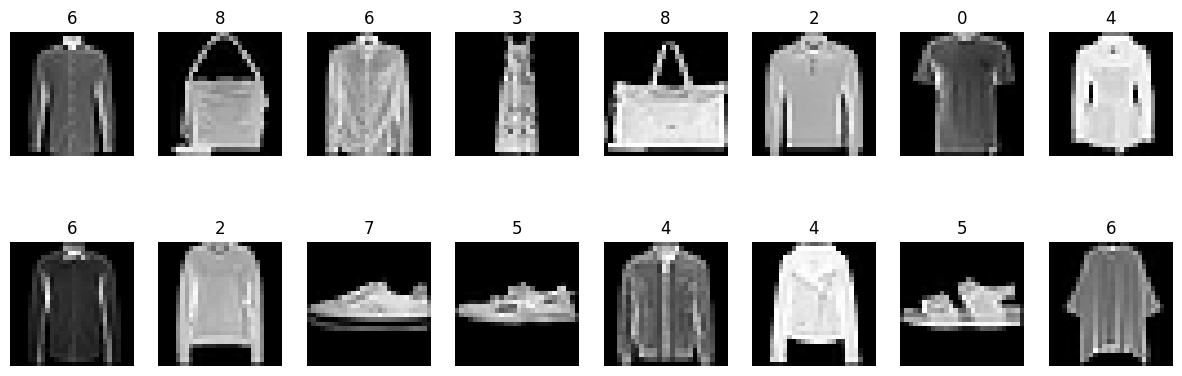

In [12]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,8,figsize=(15,5))
axes = axes.flatten()

for i in range(16):

    axes[i].imshow(images[i].squeeze(),cmap='gray')
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()

## 4️⃣ CNN Model

In [13]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Linear(128*7*7,128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)

        x = x.view(x.size(0),-1)

        x = self.fc(x)

        return x

## 5️⃣ Train Model

In [14]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 5

history = []

for epoch in range(epochs):

    epoch_loss = 0

    for images,labels in tqdm(train_loader):

        outputs = model(images)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    history.append(epoch_loss/len(train_loader))

    print("Epoch",epoch+1,"Loss",history[-1])

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 Loss 0.5334885050334147


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 Loss 0.33294662826065063


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3 Loss 0.2764928986443512


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 4 Loss 0.2443816079053162


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 5 Loss 0.21927376483072605


## 6️⃣ Training Loss Visualization

In [ ]:
plt.plot(history,marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

## 7️⃣ Feature Map Visualization

In [ ]:
def visualize_feature_maps(model,image):

    x = image.unsqueeze(0)

    feature_maps = []

    with torch.no_grad():

        for layer in model.conv:

            x = layer(x)

            if isinstance(layer,nn.Conv2d):

                feature_maps.append(x)

    fmap = feature_maps[0]

    fig,axes = plt.subplots(1,6,figsize=(15,5))

    for i in range(6):

        axes[i].imshow(fmap[0,i].cpu(),cmap='viridis')
        axes[i].axis('off')

    plt.show()

visualize_feature_maps(model,images[0])

## 8️⃣ Model Evaluation

In [ ]:
all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in test_loader:

        outputs=model(images)

        _,preds=torch.max(outputs,1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

## 9️⃣ Accuracy

In [ ]:
accuracy = np.mean(np.array(all_preds)==np.array(all_labels))

print("Accuracy:",accuracy*100)

## 🔟 Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## 11️⃣ Prediction Visualization

In [ ]:
test_images,test_labels = next(iter(test_loader))

with torch.no_grad():

    outputs=model(test_images)

    _,preds=torch.max(outputs,1)

fig,axes = plt.subplots(3,6,figsize=(15,8))

axes=axes.flatten()

for i in range(18):

    img=test_images[i].squeeze()

    true=test_labels[i].item()

    pred=preds[i].item()

    color='green' if true==pred else 'red'

    axes[i].imshow(img,cmap='gray')

    axes[i].set_title(f"T:{true} P:{pred}",color=color)

    axes[i].axis('off')

plt.show()